# Ingesta y limpieza de datos



## Descripción del dataset

El dataset utilizado corresponde a un registro real de facturación proveniente del sistema de gestión de la empresa donde me desempeño.

Por motivos de confidencialidad, los datos fueron anonimizados y tratados previamente para su análisis.

Cabe destacar que el dataset incluye tanto facturas emitidas como notas de crédito, por lo que los importes analizados corresponden a valores netos.

## Conexión a Google Drive

Se estableció la conexión con Google Drive para acceder al dataset de forma persistente.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Acceso al dataset

In [9]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Listado de facturacion.csv", sep=";", encoding="latin1")
df.head()

/tmp/ipykernel_7208/1392799481.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Listado de facturacion.csv", sep=";", encoding="latin1")


,ï»¿Tipo,Cuenta,Fecha,Razon Social,Total,Motivo NC,Reparto,Estado
0,C,596588.0,2/1/2025,SHAOHUI GUO,"-275400,26",No lo quiere,1009 ARIEL,Pagada
1,C,596632.0,2/1/2025,WANG YAPING Aut.,"-29466,66",No lo quiere,1009 ARIEL,Pagada
2,C,596647.0,2/1/2025,Yun Yunqin,"-25669,82",No pedido,1009 ARIEL,Pagada
3,C,596647.0,2/1/2025,Yun Yunqin,"-1526,4",Desc. especiales,1009 ARIEL,Pagada
4,C,17189.0,2/1/2025,BENFEI ZHENG,"-6230,65",No lo quiere,TATA 3010,Pagada


## Carga del dataset

Se procede a cargar el dataset en formato CSV utilizando la librería pandas para su posterior análisis.


In [10]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Listado de facturacion.csv", sep=";", encoding="latin1")
df.head()

/tmp/ipykernel_7208/1392799481.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Listado de facturacion.csv", sep=";", encoding="latin1")


,ï»¿Tipo,Cuenta,Fecha,Razon Social,Total,Motivo NC,Reparto,Estado
0,C,596588.0,2/1/2025,SHAOHUI GUO,"-275400,26",No lo quiere,1009 ARIEL,Pagada
1,C,596632.0,2/1/2025,WANG YAPING Aut.,"-29466,66",No lo quiere,1009 ARIEL,Pagada
2,C,596647.0,2/1/2025,Yun Yunqin,"-25669,82",No pedido,1009 ARIEL,Pagada
3,C,596647.0,2/1/2025,Yun Yunqin,"-1526,4",Desc. especiales,1009 ARIEL,Pagada
4,C,17189.0,2/1/2025,BENFEI ZHENG,"-6230,65",No lo quiere,TATA 3010,Pagada


## Selección de variables relevantes

Se seleccionaron únicamente las columnas necesarias para el análisis, eliminando las de carácter operativo o técnico que no aportaban valor analítico.

In [11]:
df = df[["Fecha", "Razon Social", "Total", "ï»¿Tipo", "Estado", "Motivo NC", "Reparto"]]
df.head()

,Fecha,Razon Social,Total,ï»¿Tipo,Estado,Motivo NC,Reparto
0,2/1/2025,SHAOHUI GUO,"-275400,26",C,Pagada,No lo quiere,1009 ARIEL
1,2/1/2025,WANG YAPING Aut.,"-29466,66",C,Pagada,No lo quiere,1009 ARIEL
2,2/1/2025,Yun Yunqin,"-25669,82",C,Pagada,No pedido,1009 ARIEL
3,2/1/2025,Yun Yunqin,"-1526,4",C,Pagada,Desc. especiales,1009 ARIEL
4,2/1/2025,BENFEI ZHENG,"-6230,65",C,Pagada,No lo quiere,TATA 3010


## Renombrado de variables


In [12]:
df.columns

Index(['Fecha', 'Razon Social', 'Total', 'ï»¿Tipo', 'Estado', 'Motivo NC',
       'Reparto'],
      dtype='object')

In [13]:
df = df.rename(columns={
    "fecha":"Fecha",
    "Razon Social": "Cliente",
    "Total": "Importe",
    "ï»¿Tipo": "Tipo",
    "motivo_nc":"Motivo NC"
})

df.head()

,Fecha,Cliente,Importe,Tipo,Estado,Motivo NC,Reparto
0,2/1/2025,SHAOHUI GUO,"-275400,26",C,Pagada,No lo quiere,1009 ARIEL
1,2/1/2025,WANG YAPING Aut.,"-29466,66",C,Pagada,No lo quiere,1009 ARIEL
2,2/1/2025,Yun Yunqin,"-25669,82",C,Pagada,No pedido,1009 ARIEL
3,2/1/2025,Yun Yunqin,"-1526,4",C,Pagada,Desc. especiales,1009 ARIEL
4,2/1/2025,BENFEI ZHENG,"-6230,65",C,Pagada,No lo quiere,TATA 3010


## Limpieza de la variable reparto

La variable "Reparto" contenía información adicional junto al código numérico, por lo que se decidió conservar únicamente el identificador para facilitar el análisis.

Además, se observó que los valores aparecían con formato decimal (por ejemplo, 1009.0) debido al tipo de dato asignado por pandas, por lo que se los convirtió a enteros para mejorar la presentación del dataset.

In [14]:
df["Reparto"] = df["Reparto"].astype(str).str.extract(r"(\d+)")
df["Reparto"] = pd.to_numeric(df["Reparto"], errors="coerce")

df.head()

,Fecha,Cliente,Importe,Tipo,Estado,Motivo NC,Reparto
0,2/1/2025,SHAOHUI GUO,"-275400,26",C,Pagada,No lo quiere,1009.0
1,2/1/2025,WANG YAPING Aut.,"-29466,66",C,Pagada,No lo quiere,1009.0
2,2/1/2025,Yun Yunqin,"-25669,82",C,Pagada,No pedido,1009.0
3,2/1/2025,Yun Yunqin,"-1526,4",C,Pagada,Desc. especiales,1009.0
4,2/1/2025,BENFEI ZHENG,"-6230,65",C,Pagada,No lo quiere,3010.0


In [15]:
df["Reparto"] = df["Reparto"].astype("Int64")
df.head()

,Fecha,Cliente,Importe,Tipo,Estado,Motivo NC,Reparto
0,2/1/2025,SHAOHUI GUO,"-275400,26",C,Pagada,No lo quiere,1009
1,2/1/2025,WANG YAPING Aut.,"-29466,66",C,Pagada,No lo quiere,1009
2,2/1/2025,Yun Yunqin,"-25669,82",C,Pagada,No pedido,1009
3,2/1/2025,Yun Yunqin,"-1526,4",C,Pagada,Desc. especiales,1009
4,2/1/2025,BENFEI ZHENG,"-6230,65",C,Pagada,No lo quiere,3010


## Conversión de fechas

La variable "Fecha" se convirtió a formato datetime para poder trabajarla correctamente en el análisis temporal.

Luego, se revisaron los valores nulos y se detectó un único registro faltante, el cual fue eliminado para asegurar la calidad de los datos.

In [16]:
df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True, errors="coerce")

df.head()

,Fecha,Cliente,Importe,Tipo,Estado,Motivo NC,Reparto
0,2025-01-02,SHAOHUI GUO,"-275400,26",C,Pagada,No lo quiere,1009
1,2025-01-02,WANG YAPING Aut.,"-29466,66",C,Pagada,No lo quiere,1009
2,2025-01-02,Yun Yunqin,"-25669,82",C,Pagada,No pedido,1009
3,2025-01-02,Yun Yunqin,"-1526,4",C,Pagada,Desc. especiales,1009
4,2025-01-02,BENFEI ZHENG,"-6230,65",C,Pagada,No lo quiere,3010


In [17]:
df["Fecha"].dtype

dtype('<M8[ns]')

In [18]:
df["Fecha"].isna().sum()

np.int64(1)

In [19]:
df[df["Fecha"].isna()]

,Fecha,Cliente,Importe,Tipo,Estado,Motivo NC,Reparto
359884,NaT,1,NaN,Dev. por rotura,NaN,NaN,<NA>


In [20]:
df = df.dropna(subset=["Fecha"])

In [21]:
df["Fecha"].isna().sum()

np.int64(0)

## Conversión de importes

La variable "Importe" se convirtió a formato numérico para poder utilizarla correctamente en los cálculos y visualizaciones.

Luego, se revisaron los valores nulos y se detectaron algunos registros con importes faltantes o mal convertidos. Estas filas se analizaron y, dado que no aportaban información relevante, se eliminaron.


In [22]:
df["Importe"] = df["Importe"].astype(str).str.replace(",", ".", regex=False)
df["Importe"] = pd.to_numeric(df["Importe"], errors="coerce")

df.head()

,Fecha,Cliente,Importe,Tipo,Estado,Motivo NC,Reparto
0,2025-01-02,SHAOHUI GUO,-275400.26,C,Pagada,No lo quiere,1009
1,2025-01-02,WANG YAPING Aut.,-29466.66,C,Pagada,No lo quiere,1009
2,2025-01-02,Yun Yunqin,-25669.82,C,Pagada,No pedido,1009
3,2025-01-02,Yun Yunqin,-1526.40,C,Pagada,Desc. especiales,1009
4,2025-01-02,BENFEI ZHENG,-6230.65,C,Pagada,No lo quiere,3010


In [23]:
df["Importe"].isna().sum()

np.int64(241)

In [24]:
df.loc[df["Importe"].isna(), ["Fecha", "Tipo", "Estado", "Motivo NC", "Reparto"]].head(20)

,Fecha,Tipo,Estado,Motivo NC,Reparto
6,2025-01-02,C,NaN,NaN,<NA>
306,2025-01-02,F,NaN,NaN,<NA>
332,2025-01-02,F,NaN,NaN,<NA>
1393,2025-01-03,F,NaN,NaN,<NA>
1905,2025-01-06,C,NaN,NaN,<NA>
2067,2025-01-06,F,NaN,NaN,<NA>
2101,2025-01-06,F,NaN,NaN,<NA>
5013,2025-01-09,F,NaN,NaN,<NA>
5245,2025-01-09,F,NaN,NaN,<NA>
6394,2025-01-10,F,NaN,NaN,<NA>


In [25]:
df = df.dropna(subset=["Importe"])

In [26]:
df["Importe"].isna().sum()

np.int64(0)

## Anonimización de clientes

Con el objetivo de preservar la confidencialidad de la información, se reemplazaron los nombres de los clientes por identificadores genéricos.


In [27]:
df["Cliente_ID"] = df["Cliente"].astype("category").cat.codes
df["Cliente_ID"] = df["Cliente_ID"].apply(lambda x: f"Cliente_{x:03}")

df.head()

,Fecha,Cliente,Importe,Tipo,Estado,Motivo NC,Reparto,Cliente_ID
0,2025-01-02,SHAOHUI GUO,-275400.26,C,Pagada,No lo quiere,1009,Cliente_7331
1,2025-01-02,WANG YAPING Aut.,-29466.66,C,Pagada,No lo quiere,1009,Cliente_8298
2,2025-01-02,Yun Yunqin,-25669.82,C,Pagada,No pedido,1009,Cliente_9294
3,2025-01-02,Yun Yunqin,-1526.40,C,Pagada,Desc. especiales,1009,Cliente_9294
4,2025-01-02,BENFEI ZHENG,-6230.65,C,Pagada,No lo quiere,3010,Cliente_689


In [28]:
df = df.drop(columns=["Cliente"])
df.head()

,Fecha,Importe,Tipo,Estado,Motivo NC,Reparto,Cliente_ID
0,2025-01-02,-275400.26,C,Pagada,No lo quiere,1009,Cliente_7331
1,2025-01-02,-29466.66,C,Pagada,No lo quiere,1009,Cliente_8298
2,2025-01-02,-25669.82,C,Pagada,No pedido,1009,Cliente_9294
3,2025-01-02,-1526.40,C,Pagada,Desc. especiales,1009,Cliente_9294
4,2025-01-02,-6230.65,C,Pagada,No lo quiere,3010,Cliente_689


## Revisión general del dataset

Se realizó una revisión de valores nulos en el dataset, observándose que las variables "Estado", "Motivo NC" y "Zona" presentan datos faltantes. Dado que estas variables no son fundamentales para el análisis principal, se decidió conservar dichos registros.

Por otro lado, se identificaron posibles registros duplicados, sin embargo, al no contar con un identificador único de cada operación (como un número de comprobante), no es posible asegurar si se trata de duplicados reales o de transacciones distintas con valores similares, por lo cual, se optó por no eliminar dichos registros, evitando así la posible pérdida de información relevante.

In [29]:
df.isnull().sum()

,0
Fecha,0
Importe,0
Tipo,0
Estado,359
Motivo NC,323508
Reparto,23301
Cliente_ID,0


In [30]:
df.duplicated().sum()

np.int64(7789)

In [31]:
df[df.duplicated(keep=False)]


,Fecha,Importe,Tipo,Estado,Motivo NC,Reparto,Cliente_ID
123,2025-01-02,3505.75,D,Anulada,Nc mal realizada,<NA>,Cliente_1590
127,2025-01-02,3505.75,D,Anulada,Nc mal realizada,<NA>,Cliente_1590
772,2025-01-02,54959.67,F,Anulada,NaN,3001,Cliente_7554
804,2025-01-02,54959.67,F,Anulada,NaN,3001,Cliente_7554
1749,2025-01-06,-54959.67,C,Anulada,Sin Dinero,<NA>,Cliente_7554
...,...,...,...,...,...,...,...
367515,2026-04-03,5286187.50,F,Pagada,NaN,1,Cliente_1147
367558,2026-04-03,17277.81,F,Pendiente,NaN,2000,Cliente_5411
367559,2026-04-03,17277.81,F,Pendiente,NaN,2000,Cliente_5411
369096,2026-04-06,72475.32,F,Pendiente,NaN,1010,Cliente_6038


# Exploración y visualización de datos



## Evolución de los importes en el tiempo

Se analizó la evolución de los importes a lo largo del tiempo con el objetivo de identificar tendencias, variaciones y posibles patrones en las operaciones.

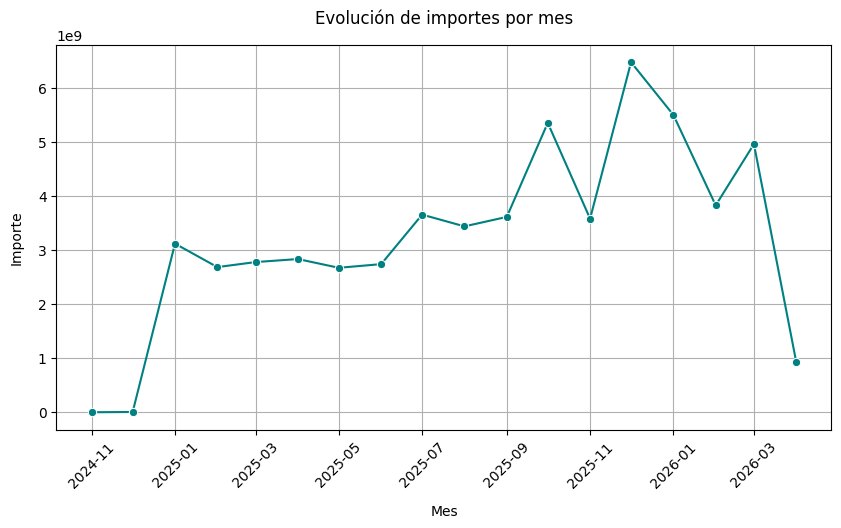

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

ventas_mes = df.groupby(df["Fecha"].dt.to_period("M"))["Importe"].sum()
ventas_mes.index = ventas_mes.index.to_timestamp()

plt.figure(figsize=(10,5))

sns.lineplot(x=ventas_mes.index, y=ventas_mes.values, marker="o", color="teal")

plt.title("Evolución de importes por mes", pad=15)
plt.xlabel("Mes", labelpad=10)
plt.ylabel("Importe", labelpad=10)

plt.xticks(rotation=45)
plt.grid()

plt.show()

In [39]:
print("Última fecha registrada:", df["Fecha"].max())

Última fecha registrada: 2026-04-06 00:00:00


El gráfico muestra una evolución variable de los importes a lo largo del tiempo, con incrementos y disminuciones en distintos períodos.

Se destacan picos hacia finales del período analizado y una caída significativa en el último mes. Esta última se explica porque los datos correspondientes a dicho mes se encuentran incompletos. Esto se verifica al analizar la última fecha registrada en el dataset, la cual corresponde al día 06/04/2026, lo que indica que no se dispone de información para el resto del mes lo que podría indicar una menor actividad o datos incompletos.

Cabe destacar que los valores representan importes netos del período.

## Distribución de importes por reparto

Se analizaron los importes según el reparto con el objetivo de identificar aquellas áreas con mayor volumen de operaciones.

/tmp/ipykernel_7208/3571573166.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


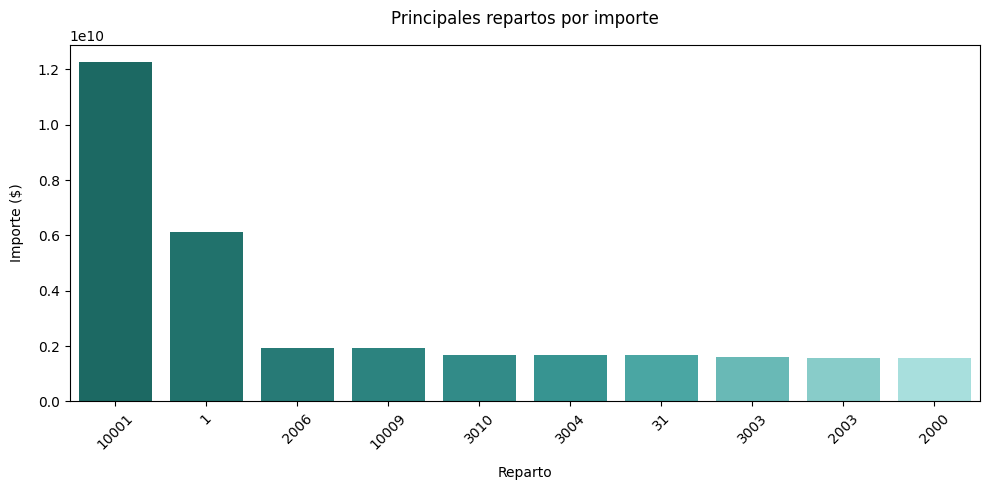

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# agrupar y ordenar
ventas_reparto = df.groupby("Reparto")["Importe"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=ventas_reparto.index.astype(str),
    y=ventas_reparto.values,
    palette=["#0f766e", "#147f78", "#198882", "#1e918c", "#239a96",
    "#28a3a0", "#3bb5b1", "#5cc6c2", "#7dd7d3", "#9fe8e5"])

plt.title("Principales repartos por importe", pad=15)
plt.xlabel("Reparto", labelpad=10)
plt.ylabel("Importe ($)", labelpad=10)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

El gráfico muestra la distribución de los importes según el reparto, observándose una fuerte concentración en algunos casos específicos.

En particular, el código 10001, correspondiente al retiro en depósito, presenta el mayor volumen, mientras que el código 1 se asocia a un cliente con alta facturación. El resto de los repartos exhibe valores considerablemente menores, lo que muestra que tienen una participación más reducida dentro del total de operaciones.

Como la cantidad de repartos es alta, se decidió mostrar únicamente los de mayor volumen para que el gráfico sea más claro. Esto se debe también a que con el tiempo algunos repartos dejaron de utilizarse y se incorporaron nuevos.



## Distribución de importes por cliente

Se analizaron los importes según el cliente con el objetivo de identificar el grado de concentración de la facturación.

/tmp/ipykernel_7208/921770482.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


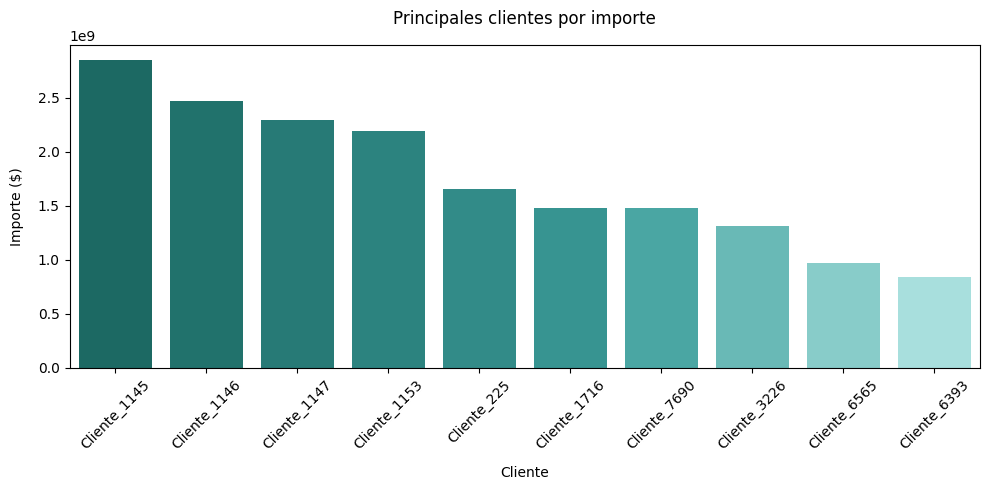

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# agrupar y ordenar
top_clientes = df.groupby("Cliente_ID")["Importe"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_clientes.index.astype(str),
    y=top_clientes.values,
    palette=["#0f766e", "#147f78", "#198882", "#1e918c", "#239a96","#28a3a0", "#3bb5b1", "#5cc6c2", "#7dd7d3", "#9fe8e5"
])

plt.title("Principales clientes por importe", pad=15)
plt.xlabel("Cliente", labelpad=10)
plt.ylabel("Importe ($)", labelpad=10)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

El gráfico muestra cómo se distribuyen los importes entre los principales clientes, y se observa que la facturación está bastante concentrada en unos pocos.

Dado el elevado número de clientes, se optó por representar únicamente aquellos con mayor volumen de importes, con el fin de facilitar la interpretación del gráfico.

## Distribución de comprobantes por estado

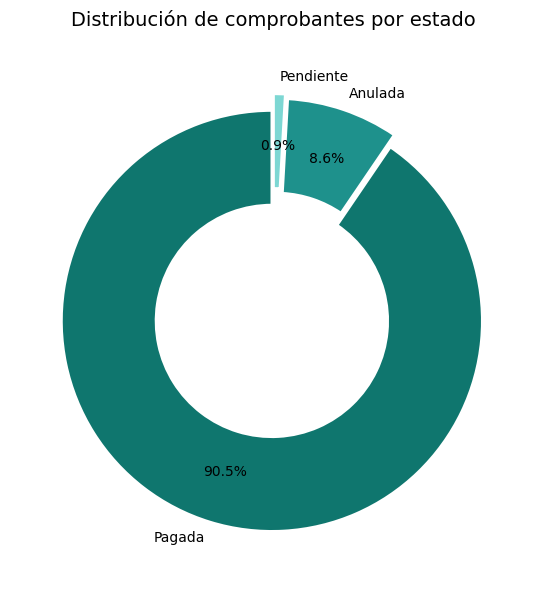

In [36]:
import matplotlib.pyplot as plt

conteo_estado = df["Estado"].value_counts()

colors = [
    "#0f766e",
    "#1e918c",
    "#7dd7d3"
]

plt.figure(figsize=(6,6))

plt.pie(
    conteo_estado,
    labels=conteo_estado.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.75,
    labeldistance=1.08,
    explode=[0.02, 0.04, 0.06],
    wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2}
)

plt.title("Distribución de comprobantes por estado", fontsize=14, pad=20)

plt.tight_layout()
plt.show()

El gráfico muestra cómo se distribuyen los comprobantes según su estado. Se ve claramente que la gran mayoría corresponde a comprobantes pagados, lo que indica que la mayor parte de la facturación ya fue efectivamente cobrada.

Por otro lado, los comprobantes anulados representan una proporción bastante menor, y los pendientes son muy pocos en comparación con el total.

En general, esto indica que la mayoría de las operaciones se cobran sin inconvenientes y que los casos pendientes o con problemas son poco frecuentes.

# Conclusión final


A lo largo del análisis se pudieron identificar distintos comportamientos en la facturación.

Se observa que los importes varían en el tiempo y que una parte importante se concentra en algunos clientes y repartos específicos. Esto muestra que la facturación no se distribuye de manera uniforme, sino que depende en gran medida de ciertos casos puntuales.

Por otro lado, la mayoría de los comprobantes se encuentra en estado pagado, lo que indica que las operaciones se cobran en su gran mayoría y que los casos pendientes son pocos.

Además, se definieron indicadores clave (KPIs) como el total facturado, la cantidad de comprobantes emitidos y la cantidad de clientes facturados, los cuales permiten resumir la información más relevante del análisis y facilitan una comprensión rápida del desempeño general.

En conjunto, el análisis permite tener una visión más clara del funcionamiento de la facturación y de las principales características del negocio.

## Exportación del dataset final

In [37]:
df.to_csv("Listado de facturacion limpio y anonimizado.csv", index=False)

In [38]:
from google.colab import files
files.download("Listado de facturacion limpio y anonimizado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>